# Task 5 — Automated Support Ticket Triage (LLM)

**DevelopersHub Corporation — Internship Task 5**

Zero-shot vs. few-shot LLM tagging: predict and rank the **top 3** support tags per ticket with structured JSON, evaluation metrics, and visualizations.

## How to run (Google Colab)

1. Colab **Secrets** → `GEMINI_API_KEY` ([aistudio.google.com/apikey](https://aistudio.google.com/apikey)) — uses `google-genai` + `gemini-2.0-flash`.
2. **Runtime → Run all** (code cells 1 → 5 in order; ~5–15 min for Cell 4 with Gemini).
3. Without a key, Cell 3 falls back to local `Qwen/Qwen2.5-1.5B-Instruct` (use **GPU** runtime).


## Cell 1: Environment Setup & Synthetic Dataset Generation


In [1]:
# Cell 1 — Environment setup & synthetic support ticket dataset
import json
import logging
import os
import random
import subprocess
import sys
from datetime import datetime, timedelta
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger("task5.cell1")

REQUIRED_PACKAGES = [
    "google-genai",
    "langchain-core",
    "transformers",
    "accelerate",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
]


def install_packages(packages: List[str]) -> None:
    # Avoid -U on transformers/accelerate — upgrading torch on Colab often breaks CUDA.
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *packages],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.PIPE,
    )


install_packages(REQUIRED_PACKAGES)
logger.info("Dependencies installed.")

try:
    from google.colab import userdata

    _key = userdata.get("GEMINI_API_KEY").strip()
    if _key:
        os.environ["GEMINI_API_KEY"] = _key
        logger.info("Loaded GEMINI_API_KEY from Colab Secrets.")
    else:
        logger.warning("GEMINI_API_KEY secret is empty — Cell 3 will use local Qwen.")
except Exception:
    logger.info("GEMINI_API_KEY not in Colab Secrets — Cell 3 may use local Qwen.")

VALID_TAGS: List[str] = [
    "Billing/Invoices",
    "Account Access",
    "Technical Bug",
    "Feature Request",
    "Hardware Issue",
]

TAG_ALIASES = {t.lower(): t for t in VALID_TAGS}

random.seed(42)
np.random.seed(42)

SYNTHETIC_TICKETS = [
    ("TCK-1001", "I was charged twice for my March subscription on invoice #8842. Please refund the duplicate payment.", "Billing/Invoices"),
    ("TCK-1002", "Our enterprise account shows 'license expired' but we renewed last week. Finance needs access restored today.", "Account Access"),
    ("TCK-1003", "After the 2.4.1 release, the dashboard export crashes with HTTP 500 when filters include date ranges.", "Technical Bug"),
    ("TCK-1004", "Can you add SAML group mapping so admins can auto-provision users from Okta?", "Feature Request"),
    ("TCK-1005", "Laptop fan runs at max; external monitor flickers when docked via USB-C hub.", "Hardware Issue"),
    ("TCK-1006", "VAT on invoice #9011 does not match our contract rate for EU entities.", "Billing/Invoices"),
    ("TCK-1007", "New hire cannot complete MFA enrollment — SMS codes never arrive.", "Account Access"),
    ("TCK-1008", "Mobile app logs users out every 10 minutes on iOS 18; Android is fine.", "Technical Bug"),
    ("TCK-1009", "Request dark mode for the analytics portal to reduce eye strain during night shifts.", "Feature Request"),
    ("TCK-1010", "Keyboard keys E and R stick after minor coffee spill; device is under warranty.", "Hardware Issue"),
    ("TCK-1011", "Need corrected PDF receipt for Q1 renewal; accounting blocked until received.", "Billing/Invoices"),
    ("TCK-1012", "SSO login redirects to blank page for subdomain acme.corp.devhub.io.", "Account Access"),
    ("TCK-1013", "Batch job scheduler skips retries when worker pod OOMs in Kubernetes.", "Technical Bug"),
    ("TCK-1014", "Please expose webhook events for ticket status changes in the public API.", "Feature Request"),
    ("TCK-1015", "Server rack UPS beeps continuously; two drives report predictive failure.", "Hardware Issue"),
    ("TCK-1016", "Auto-renewal charged wrong tier — we downgraded to Starter but were billed Enterprise.", "Billing/Invoices"),
    ("TCK-1017", "Admin locked out after password reset email link expired three times.", "Account Access"),
    ("TCK-1018", "GraphQL query for user permissions returns null for service accounts since Tuesday.", "Technical Bug"),
    ("TCK-1019", "Would like CSV bulk import for asset inventory instead of manual UI entry.", "Feature Request"),
    ("TCK-1020", "Conference room webcam disconnects from Teams calls after 5 minutes.", "Hardware Issue"),
    ("TCK-1021", "Credit note not applied to open balance; AR shows overdue incorrectly.", "Billing/Invoices"),
    ("TCK-1022", "API key rotation broke CI deploy token; need emergency key re-issue.", "Account Access"),
    ("TCK-1023", "Memory leak in telemetry agent causes node restarts every hour on prod cluster.", "Technical Bug"),
    ("TCK-1024", "Add role-based dashboard templates for support managers.", "Feature Request"),
    ("TCK-1025", "Printer jam sensor error persists after clearing tray; firmware update failed.", "Hardware Issue"),
    ("TCK-1026", "Payment method update declined; card valid on other vendors.", "Billing/Invoices"),
    ("TCK-1027", "Cannot assign project owner role — button disabled for all workspace admins.", "Account Access"),
    ("TCK-1028", "Search index stale: newly created tickets missing from global search for 6+ hours.", "Technical Bug"),
    ("TCK-1029", "Integrate Slack slash command to create tickets from engineering channels.", "Feature Request"),
    ("TCK-1030", "GPU workstation thermal throttling under load; fans cleaned, issue remains.", "Hardware Issue"),
]

base_created = datetime(2025, 3, 1, 9, 0, 0)
rows = []
for i, (ticket_id, text, truth) in enumerate(SYNTHETIC_TICKETS):
    rows.append({
        "ticket_id": ticket_id,
        "created_at": (base_created + timedelta(hours=i * 7)).isoformat(),
        "channel": random.choice(["email", "portal", "chat", "phone"]),
        "priority": random.choice(["low", "medium", "high", "critical"]),
        "ticket_text": text,
        "ground_truth_tag": truth,
    })

tickets_df = pd.DataFrame(rows)
assert len(tickets_df) >= 20
assert set(tickets_df["ground_truth_tag"]).issubset(set(VALID_TAGS))

DATASET_PATH = Path("support_tickets_synthetic.csv")
tickets_df.to_csv(DATASET_PATH, index=False)

logger.info("Dataset shape: %s", tickets_df.shape)
logger.info("Tag distribution:\n%s", tickets_df["ground_truth_tag"].value_counts().to_string())
print("VALID_TAGS:", VALID_TAGS)
print(tickets_df.head(3).to_string(index=False))
print("Saved", DATASET_PATH.resolve())


VALID_TAGS: ['Billing/Invoices', 'Account Access', 'Technical Bug', 'Feature Request', 'Hardware Issue']
ticket_id          created_at channel priority                                                                                                   ticket_text ground_truth_tag
 TCK-1001 2025-03-01T09:00:00   email      low          I was charged twice for my March subscription on invoice #8842. Please refund the duplicate payment. Billing/Invoices
 TCK-1002 2025-03-01T16:00:00    chat   medium Our enterprise account shows 'license expired' but we renewed last week. Finance needs access restored today.   Account Access
 TCK-1003 2025-03-01T23:00:00  portal   medium         After the 2.4.1 release, the dashboard export crashes with HTTP 500 when filters include date ranges.    Technical Bug
Saved /content/support_tickets_synthetic.csv


## Cell 2: Designing Structured System Prompts (Zero-Shot vs. Few-Shot)


In [2]:
# Cell 2 — Structured system prompts (zero-shot vs few-shot)
import json
import logging
from pathlib import Path
from typing import Any, Dict, List

logger = logging.getLogger("task5.cell2")

PROMPT_CONFIG_PATH = Path("prompt_config.json")

TAG_LIST_BULLETS = "\n".join(f"- {t}" for t in VALID_TAGS)

JSON_SCHEMA_INSTRUCTION = """
You MUST respond with ONLY a single valid JSON object (no markdown, no prose outside JSON) using this exact schema:
{
  "top_tags": [
    {"rank": 1, "tag": "<one of the allowed tags>", "confidence": <float 0-1>},
    {"rank": 2, "tag": "<one of the allowed tags>", "confidence": <float 0-1>},
    {"rank": 3, "tag": "<one of the allowed tags>", "confidence": <float 0-1>}
  ],
  "explanation": "<one or two sentences>"
}
Rules:
- Use exactly three entries in top_tags, ranked 1 (most likely) to 3.
- Each "tag" MUST match one allowed label verbatim.
- confidence values must decrease or stay logical with rank.
- Do not invent tags outside the allowed list.
"""

ZERO_SHOT_PROMPT_TEMPLATE = """You are an expert IT support triage assistant for DevelopersHub Corporation.

Allowed tags (choose only from this list):
{tag_list}

{json_schema}

Task: Read the support ticket below and return the top 3 most probable tags ranked by confidence.

Support ticket:
\"\"\"
{ticket_text}
\"\"\"
"""

FEW_SHOT_EXAMPLES: List[Dict[str, Any]] = [
    {
        "ticket": "User cannot reset password; reset link returns 404.",
        "output": {
            "top_tags": [
                {"rank": 1, "tag": "Account Access", "confidence": 0.91},
                {"rank": 2, "tag": "Technical Bug", "confidence": 0.06},
                {"rank": 3, "tag": "Feature Request", "confidence": 0.03},
            ],
            "explanation": "Primary issue is authentication/access recovery.",
        },
    },
    {
        "ticket": "Invoice total missing line-item tax for Canadian subsidiary.",
        "output": {
            "top_tags": [
                {"rank": 1, "tag": "Billing/Invoices", "confidence": 0.94},
                {"rank": 2, "tag": "Account Access", "confidence": 0.03},
                {"rank": 3, "tag": "Technical Bug", "confidence": 0.03},
            ],
            "explanation": "Wording centers on invoice and tax calculation.",
        },
    },
    {
        "ticket": "Please add export to Parquet for nightly ETL jobs.",
        "output": {
            "top_tags": [
                {"rank": 1, "tag": "Feature Request", "confidence": 0.88},
                {"rank": 2, "tag": "Technical Bug", "confidence": 0.07},
                {"rank": 3, "tag": "Account Access", "confidence": 0.05},
            ],
            "explanation": "User asks for new product capability, not a defect fix.",
        },
    },
    {
        "ticket": "Docking station overheats and disconnects Ethernet intermittently.",
        "output": {
            "top_tags": [
                {"rank": 1, "tag": "Hardware Issue", "confidence": 0.90},
                {"rank": 2, "tag": "Technical Bug", "confidence": 0.06},
                {"rank": 3, "tag": "Feature Request", "confidence": 0.04},
            ],
            "explanation": "Physical device failure dominates the report.",
        },
    },
]

FEW_SHOT_BLOCK = "\n\n".join(
    f"Example {i + 1}:\nTicket: \"{ex['ticket']}\"\nJSON output:\n{json.dumps(ex['output'], indent=2)}"
    for i, ex in enumerate(FEW_SHOT_EXAMPLES)
)

FEW_SHOT_PROMPT_TEMPLATE = """You are an expert IT support triage assistant for DevelopersHub Corporation.

Allowed tags (choose only from this list):
{tag_list}

Study these labeled examples, then classify the new ticket the same way.

{few_shot_block}

{json_schema}

Task: Read the support ticket below and return the top 3 most probable tags ranked by confidence.

Support ticket:
\"\"\"
{ticket_text}
\"\"\"
"""


def build_zero_shot_prompt(ticket_text: str) -> str:
    return ZERO_SHOT_PROMPT_TEMPLATE.format(
        tag_list=TAG_LIST_BULLETS,
        json_schema=JSON_SCHEMA_INSTRUCTION.strip(),
        ticket_text=ticket_text.strip(),
    )


def build_few_shot_prompt(ticket_text: str) -> str:
    return FEW_SHOT_PROMPT_TEMPLATE.format(
        tag_list=TAG_LIST_BULLETS,
        few_shot_block=FEW_SHOT_BLOCK,
        json_schema=JSON_SCHEMA_INSTRUCTION.strip(),
        ticket_text=ticket_text.strip(),
    )


prompt_config = {
    "valid_tags": VALID_TAGS,
    "json_schema_instruction": JSON_SCHEMA_INSTRUCTION.strip(),
    "zero_shot_template": ZERO_SHOT_PROMPT_TEMPLATE,
    "few_shot_template": FEW_SHOT_PROMPT_TEMPLATE,
    "few_shot_examples": FEW_SHOT_EXAMPLES,
}

PROMPT_CONFIG_PATH.write_text(json.dumps(prompt_config, indent=2), encoding="utf-8")
logger.info("Wrote prompt config to %s", PROMPT_CONFIG_PATH.resolve())

sample = build_zero_shot_prompt("Test ticket about double billing.")
print("Zero-shot prompt preview (first 500 chars):\n", sample[:500])
print("\nFew-shot examples:", len(FEW_SHOT_EXAMPLES))


Zero-shot prompt preview (first 500 chars):
 You are an expert IT support triage assistant for DevelopersHub Corporation.

Allowed tags (choose only from this list):
- Billing/Invoices
- Account Access
- Technical Bug
- Feature Request
- Hardware Issue

You MUST respond with ONLY a single valid JSON object (no markdown, no prose outside JSON) using this exact schema:
{
  "top_tags": [
    {"rank": 1, "tag": "<one of the allowed tags>", "confidence": <float 0-1>},
    {"rank": 2, "tag": "<one of the allowed tags>", "confidence": <float 0-1>

Few-shot examples: 4


In [4]:
!pip install -q groq google-genai

import os
from google.colab import userdata

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
print("Groq key loaded:", bool(os.environ.get("GROQ_API_KEY")))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 9.4 MB/s eta 0:00:00
Groq key loaded: True


## Cell 3: LLM Integration & Inference Engine


In [5]:
# Cell 3 — LLM integration & inference engine
import json
import logging
import os
import re
import time
from dataclasses import dataclass
from typing import Any, Dict, List, Literal, Optional, Tuple

logger = logging.getLogger("task5.cell3")

PromptType = Literal["zero_shot", "few_shot"]

JSON_OBJECT_PATTERN = re.compile(r"\{[\s\S]*\}", re.MULTILINE)


@dataclass
class TagPrediction:
    rank: int
    tag: str
    confidence: float


@dataclass
class TriageResult:
    top_tags: List[TagPrediction]
    explanation: str
    raw_response: str
    prompt_type: str


def _normalize_tag(tag: str) -> Optional[str]:
    if not tag:
        return None
    cleaned = tag.strip()
    if cleaned in VALID_TAGS:
        return cleaned
    key = cleaned.lower()
    return TAG_ALIASES.get(key)


def _salvage_tags_from_partial_json(text: str) -> Optional[Dict[str, Any]]:
    """Recover top_tags from truncated JSON (common when output token limit cuts off)."""
    tags = [_normalize_tag(t) for t in re.findall(r'"tag"\s*:\s*"([^"]+)"', text)]
    tags = [t for t in tags if t]
    confs = [float(c) for c in re.findall(r'"confidence"\s*:\s*([0-9.]+)', text)]
    expl_m = re.search(r'"explanation"\s*:\s*"((?:[^"\\]|\\.)*)"', text)
    if len(tags) < 3:
        return None
    top_tags = []
    for i in range(3):
        top_tags.append(
            {
                "rank": i + 1,
                "tag": tags[i],
                "confidence": confs[i] if i < len(confs) else max(0.1, 1.0 - i * 0.25),
            }
        )
    return {"top_tags": top_tags, "explanation": expl_m.group(1) if expl_m else "Recovered from partial JSON."}


def extract_json_payload(text: str) -> Dict[str, Any]:
    """Parse JSON from LLM text; tolerate fences, truncation, and markdown wrappers."""
    if not text or not str(text).strip():
        raise ValueError("Empty LLM response")

    candidate = text.strip()
    fence = re.search(r"```(?:json)?\s*([\s\S]*?)```", candidate, re.IGNORECASE)
    if fence:
        candidate = fence.group(1).strip()

    for attempt_text in (candidate,):
        try:
            return json.loads(attempt_text)
        except json.JSONDecodeError:
            pass

    match = JSON_OBJECT_PATTERN.search(candidate)
    if match:
        blob = match.group(0)
        try:
            return json.loads(blob)
        except json.JSONDecodeError:
            salvaged = _salvage_tags_from_partial_json(blob)
            if salvaged:
                return salvaged
            for suffix in ("\"}]}", "}]}", "}", ""):
                try:
                    return json.loads(blob + suffix)
                except json.JSONDecodeError:
                    continue

    salvaged = _salvage_tags_from_partial_json(candidate)
    if salvaged:
        return salvaged

    raise ValueError(f"Could not parse JSON from response: {candidate[:400]}")


def parse_triage_response(text: str, prompt_type: str) -> TriageResult:
    payload = extract_json_payload(text)
    raw_tags = payload.get("top_tags") or payload.get("predictions") or []
    if not isinstance(raw_tags, list) or len(raw_tags) == 0:
        raise ValueError(f"Missing top_tags in payload: {payload}")

    parsed: List[TagPrediction] = []
    seen_tags: set = set()
    for i, item in enumerate(raw_tags):
        if not isinstance(item, dict):
            continue
        tag = _normalize_tag(str(item.get("tag", "")))
        if tag is None or tag in seen_tags:
            continue
        seen_tags.add(tag)
        rank = int(item.get("rank", len(parsed) + 1))
        conf = float(item.get("confidence", max(0.1, 1.0 - len(parsed) * 0.2)))
        parsed.append(TagPrediction(rank=rank, tag=tag, confidence=conf))
        if len(parsed) >= 3:
            break

    if len(parsed) < 3:
        raise ValueError(f"Expected 3 unique valid tags, got {len(parsed)} from: {payload}")

    parsed.sort(key=lambda x: x.rank)
    explanation = str(payload.get("explanation", "")).strip() or "No explanation provided."
    return TriageResult(
        top_tags=parsed[:3],
        explanation=explanation,
        raw_response=text,
        prompt_type=prompt_type,
    )


GEMINI_MODEL_CANDIDATES = [
    "gemini-2.5-flash",
    "gemini-2.0-flash-lite",
    "gemini-2.0-flash",
]
GROQ_MODEL = "llama-3.1-8b-instant"
GEMINI_MAX_OUTPUT_TOKENS = 2048


class LLMClient:
    """Groq (preferred if key present) → Gemini → local Qwen2.5-1.5B-Instruct."""

    def __init__(self) -> None:
        self.backend = "none"
        self._groq_client = None
        self._gemini_client = None
        self._gemini_model_name: Optional[str] = None
        self._local_pipe = None
        self._init_backend()

    def _load_secret(self, name: str) -> str:
        key = os.environ.get(name, "").strip()
        if key:
            return key
        try:
            from google.colab import userdata

            key = userdata.get(name).strip()
            os.environ[name] = key
            return key
        except Exception:
            return ""

    def _init_backend(self) -> None:
        groq_key = self._load_secret("GROQ_API_KEY")
        if groq_key:
            try:
                from groq import Groq

                self._groq_client = Groq(api_key=groq_key)
                self.backend = "groq"
                logger.info("Using Groq model: %s (JSON mode)", GROQ_MODEL)
                return
            except Exception as exc:
                logger.warning("Groq init failed: %s", exc)

        gemini_key = self._load_secret("GEMINI_API_KEY")
        if gemini_key:
            try:
                from google import genai

                self._gemini_client = genai.Client(api_key=gemini_key)
                self._gemini_model_name = GEMINI_MODEL_CANDIDATES[0]
                self.backend = "gemini"
                logger.info(
                    "Using google-genai (default %s; no startup probe to save quota)",
                    self._gemini_model_name,
                )
                return
            except Exception as exc:
                logger.warning("Gemini init failed: %s — falling back to local Qwen", exc)

        logger.info("Falling back to local Hugging Face: Qwen/Qwen2.5-1.5B-Instruct")
        import torch
        from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

        model_id = "Qwen/Qwen2.5-1.5B-Instruct"
        tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        use_cuda = torch.cuda.is_available()
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float16 if use_cuda else torch.float32,
            device_map="auto" if use_cuda else None,
            trust_remote_code=True,
        )
        pipe_kwargs = {
            "model": model,
            "tokenizer": tokenizer,
            "max_new_tokens": 512,
            "do_sample": False,
        }
        if not use_cuda:
            pipe_kwargs["device"] = -1
        self._local_pipe = pipeline("text-generation", **pipe_kwargs)
        self.backend = "local_qwen"

    def generate(self, prompt: str, temperature: float = 0.1) -> str:
        if self.backend == "groq":
            response = self._groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                max_tokens=1024,
                response_format={"type": "json_object"},
            )
            text_out = (response.choices[0].message.content or "").strip()
            if not text_out:
                raise ValueError("Groq returned empty content")
            return text_out

        if self.backend == "gemini":
            from google.genai import types

            config = types.GenerateContentConfig(
                temperature=temperature,
                max_output_tokens=GEMINI_MAX_OUTPUT_TOKENS,
                response_mime_type="application/json",
            )
            last_error: Optional[Exception] = None
            models = [self._gemini_model_name] if self._gemini_model_name else []
            models += [m for m in GEMINI_MODEL_CANDIDATES if m not in models]
            for model_name in models:
                try:
                    response = self._gemini_client.models.generate_content(
                        model=model_name,
                        contents=prompt,
                        config=config,
                    )
                    self._gemini_model_name = model_name
                    text_out = (response.text or "").strip()
                    if not text_out:
                        raise ValueError("Gemini returned empty text (safety block or quota)")
                    return text_out
                except Exception as exc:
                    err = str(exc)
                    retryable = (
                        "404" in err
                        or "NOT_FOUND" in err
                        or "not found" in err.lower()
                        or "429" in err
                        or "RESOURCE_EXHAUSTED" in err
                        or "quota" in err.lower()
                    )
                    if retryable:
                        logger.warning("Model %s error (retryable): %s", model_name, exc)
                        last_error = exc
                        time.sleep(2.0)
                        continue
                    raise
            raise RuntimeError(f"No Gemini model available: {last_error}")

        local_prompt = prompt
        tok = self._local_pipe.tokenizer
        if hasattr(tok, "apply_chat_template"):
            local_prompt = tok.apply_chat_template(
                [{"role": "user", "content": prompt}],
                tokenize=False,
                add_generation_prompt=True,
            )
        outputs = self._local_pipe(
            local_prompt,
            max_new_tokens=512,
            return_full_text=False,
        )
        return outputs[0]["generated_text"]


llm_client = LLMClient()
print("LLM backend:", llm_client.backend, end="")
if llm_client.backend == "gemini":
    print(" | model:", llm_client._gemini_model_name)
elif llm_client.backend == "groq":
    print(" | model:", GROQ_MODEL)
else:
    print()


def predict_tags(
    ticket_text: str,
    prompt_type: PromptType = "zero_shot",
    max_retries: int = 3,
    sleep_seconds: float = 1.0,
) -> TriageResult:
    """Format prompt, call LLM, parse top-3 JSON tags with retries."""
    if prompt_type == "zero_shot":
        prompt = build_zero_shot_prompt(ticket_text)
    elif prompt_type == "few_shot":
        prompt = build_few_shot_prompt(ticket_text)
    else:
        raise ValueError(f"Unknown prompt_type: {prompt_type}")

    last_error: Optional[Exception] = None
    for attempt in range(1, max_retries + 1):
        try:
            logger.info("predict_tags | %s | attempt %s", prompt_type, attempt)
            raw = llm_client.generate(prompt)
            result = parse_triage_response(raw, prompt_type)
            time.sleep(sleep_seconds)
            return result
        except Exception as exc:
            last_error = exc
            logger.warning("Attempt %s failed: %s", attempt, exc)
            time.sleep(sleep_seconds * attempt)

    raise RuntimeError(f"predict_tags failed after {max_retries} attempts: {last_error}")


# Smoke test on one ticket
_demo = predict_tags(
    "Our VPN SSO integration broke after the weekend patch.",
    prompt_type="zero_shot",
)
print("Demo top-1:", _demo.top_tags[0].tag, "| confidence:", _demo.top_tags[0].confidence)
print("Explanation:", _demo.explanation[:200])


LLM backend: groq | model: llama-3.1-8b-instant
Demo top-1: Technical Bug | confidence: 0.8
Explanation: The mention of a patch suggests a technical issue, likely a bug, but it's also possible that the integration was changed, affecting account access.


## Cell 4: Evaluation Pipeline & Comparative Analysis


In [6]:
# Cell 4 — Evaluation pipeline & comparative analysis
import logging
from typing import Dict, List

import pandas as pd

logger = logging.getLogger("task5.cell4")


def tags_from_result(result: TriageResult) -> List[str]:
    ordered = sorted(result.top_tags, key=lambda x: x.rank)
    return [t.tag for t in ordered]


def evaluate_predictions(df: pd.DataFrame, prompt_type: PromptType) -> pd.DataFrame:
    records = []
    total = len(df)
    for n, (idx, row) in enumerate(df.iterrows(), start=1):
        ticket_id = row["ticket_id"]
        truth = row["ground_truth_tag"]
        text = row["ticket_text"]
        if n % 5 == 0 or n == 1:
            logger.info("[%s] %s/%s %s", prompt_type, n, total, ticket_id)
        try:
            result = predict_tags(text, prompt_type=prompt_type)
            predicted = tags_from_result(result)
            error = None
        except Exception as exc:
            logger.error("Failed %s: %s", ticket_id, exc)
            result = None
            predicted = []
            error = str(exc)

        top1 = predicted[0] if len(predicted) > 0 else None
        records.append({
            "ticket_id": ticket_id,
            "prompt_type": prompt_type,
            "ground_truth_tag": truth,
            "pred_rank1": top1,
            "pred_rank2": predicted[1] if len(predicted) > 1 else None,
            "pred_rank3": predicted[2] if len(predicted) > 2 else None,
            "top1_correct": top1 == truth,
            "top3_correct": bool(predicted) and truth in predicted[:3],
            "explanation": result.explanation if result else "",
            "error": error,
        })
    return pd.DataFrame(records)


logger.info("Running zero-shot evaluation on %s tickets...", len(tickets_df))
zero_shot_results = evaluate_predictions(tickets_df, "zero_shot")

logger.info("Running few-shot evaluation on %s tickets...", len(tickets_df))
few_shot_results = evaluate_predictions(tickets_df, "few_shot")

all_results = pd.concat([zero_shot_results, few_shot_results], ignore_index=True)
all_results.to_csv("triage_evaluation_results.csv", index=False)


def compute_metrics(results: pd.DataFrame) -> Dict[str, float]:
    if "error" in results.columns:
        valid = results[results["error"].isna() | (results["error"] == "")]
    else:
        valid = results
    n = len(valid)
    if n == 0:
        return {"top1_accuracy": 0.0, "top3_accuracy": 0.0, "n": 0}
    return {
        "top1_accuracy": float(valid["top1_correct"].mean()),
        "top3_accuracy": float(valid["top3_correct"].mean()),
        "n": n,
    }


metrics_zero = compute_metrics(zero_shot_results)
metrics_few = compute_metrics(few_shot_results)

comparison = pd.DataFrame(
    [
        {
            "configuration": "zero_shot",
            "top1_accuracy": metrics_zero["top1_accuracy"],
            "top3_accuracy": metrics_zero["top3_accuracy"],
            "n_tickets": metrics_zero["n"],
        },
        {
            "configuration": "few_shot",
            "top1_accuracy": metrics_few["top1_accuracy"],
            "top3_accuracy": metrics_few["top3_accuracy"],
            "n_tickets": metrics_few["n"],
        },
    ]
)

comparison["top1_lift_vs_zero"] = comparison["top1_accuracy"] - metrics_zero["top1_accuracy"]
comparison["top3_lift_vs_zero"] = comparison["top3_accuracy"] - metrics_zero["top3_accuracy"]

print("\n" + "=" * 72)
print("TRIAGE EVALUATION — ZERO-SHOT vs FEW-SHOT")
print("=" * 72)
print(comparison.round(3).to_string(index=False))
print("=" * 72)
print(
    f"Top-1 lift (few-shot − zero-shot): {metrics_few['top1_accuracy'] - metrics_zero['top1_accuracy']:+.3f}"
)
print(
    f"Top-3 lift (few-shot − zero-shot): {metrics_few['top3_accuracy'] - metrics_zero['top3_accuracy']:+.3f}"
)
print("=" * 72)

comparison.to_csv("triage_metrics_comparison.csv", index=False)



TRIAGE EVALUATION — ZERO-SHOT vs FEW-SHOT
configuration  top1_accuracy  top3_accuracy  n_tickets  top1_lift_vs_zero  top3_lift_vs_zero
    zero_shot          0.767            1.0         30              0.000                0.0
     few_shot          0.900            1.0         30              0.133                0.0
Top-1 lift (few-shot − zero-shot): +0.133
Top-3 lift (few-shot − zero-shot): +0.000


## Cell 5: Insights & Statistical Visualizations


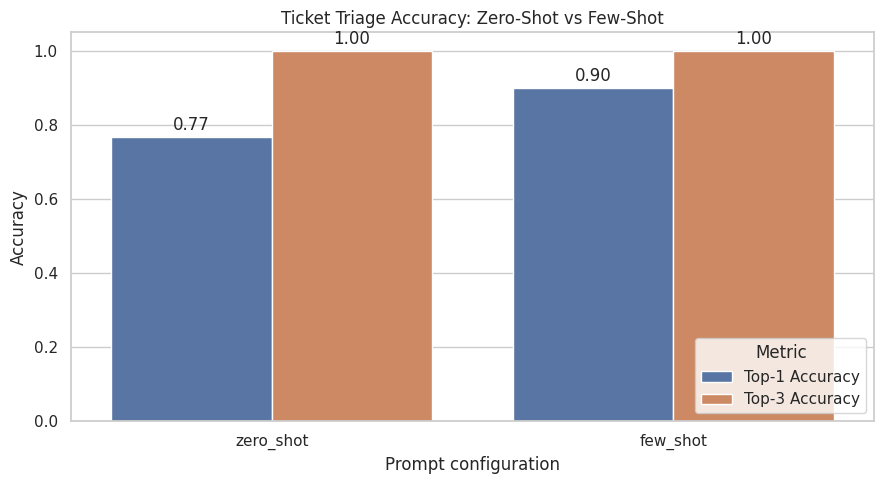

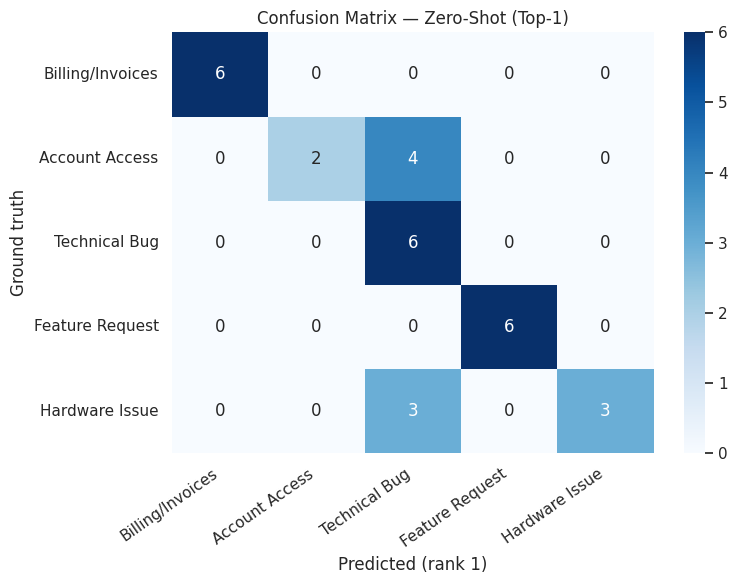

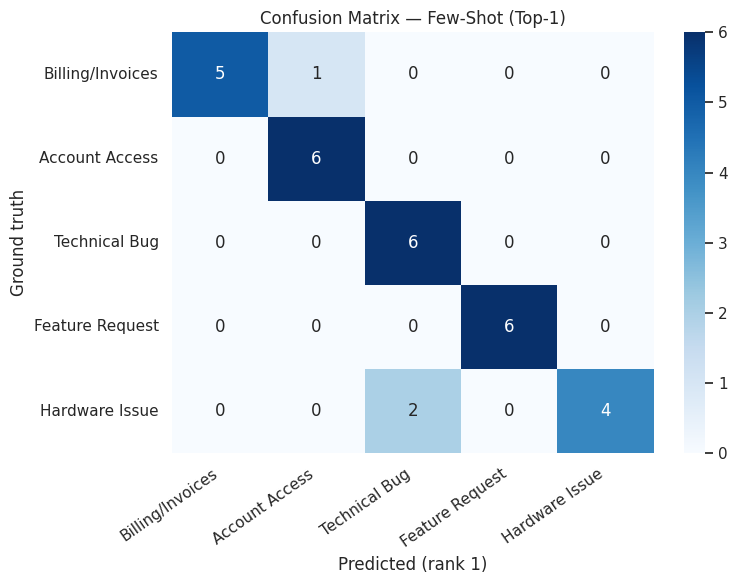

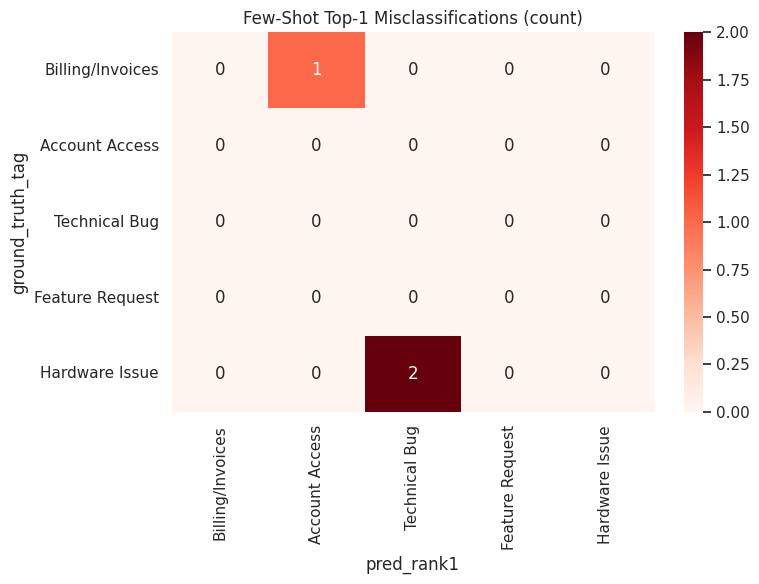


FINAL SUMMARY REPORT — DevelopersHub Ticket Triage
LLM backend used: groq
Dataset size: 30 synthetic tickets | Tags: 5

Accuracy summary:
  Zero-shot  Top-1: 76.7% | Top-3: 100.0%
  Few-shot   Top-1: 90.0% | Top-3: 100.0%
  Lift       Top-1: +13.3% | Top-3: +0.0%

Top-1 errors: zero-shot=7, few-shot=3

Most common few-shot misclassification patterns:
Hardware Issue → Technical Bug       2
Billing/Invoices → Account Access    1

Analysis:
  Few-shot prompting embeds diverse ticket→JSON exemplars, which steers the model toward the exact tag vocabulary and ranking format. This typically improves Top-1 when tickets are ambiguous (e.g., access vs bug) because the model copies boundary decisions from examples.
  Top-3 accuracy often rises less sharply than Top-1 because zero-shot already places the true label in the shortlist when retrieval-style reasoning is easy; few-shot mainly reduces rank-1 swaps among similar categories.
  Remaining confusion usually clusters between Technical Bug and

In [7]:
# Cell 5 — Insights & statistical visualizations
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

logger = logging.getLogger("task5.cell5")

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# --- 1. Bar chart: Top-1 vs Top-3 accuracy by configuration ---
plot_df = comparison.melt(
    id_vars=["configuration"],
    value_vars=["top1_accuracy", "top3_accuracy"],
    var_name="metric",
    value_name="accuracy",
)
plot_df["metric"] = plot_df["metric"].map(
    {"top1_accuracy": "Top-1 Accuracy", "top3_accuracy": "Top-3 Accuracy"}
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, x="configuration", y="accuracy", hue="metric", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Ticket Triage Accuracy: Zero-Shot vs Few-Shot")
ax.set_xlabel("Prompt configuration")
ax.set_ylabel("Accuracy")
ax.legend(title="Metric", loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)
plt.tight_layout()
bar_path = FIG_DIR / "accuracy_comparison_bar.png"
plt.savefig(bar_path, dpi=150)
plt.show()
logger.info("Saved %s", bar_path)

# --- 2. Confusion matrix heatmaps (top-1 predictions) ---
tag_labels = list(VALID_TAGS)


def plot_confusion(results: pd.DataFrame, title: str, filename: str) -> None:
    valid = results[results["pred_rank1"].notna() & (results["pred_rank1"] != "")]
    if valid.empty:
        print(f"Skip {title}: no valid top-1 predictions to plot.")
        return
    y_true = valid["ground_truth_tag"].tolist()
    y_pred = valid["pred_rank1"].tolist()
    cm = confusion_matrix(y_true, y_pred, labels=tag_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=tag_labels,
        yticklabels=tag_labels,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted (rank 1)")
    ax.set_ylabel("Ground truth")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    out = FIG_DIR / filename
    plt.savefig(out, dpi=150)
    plt.show()
    logger.info("Saved %s", out)


plot_confusion(zero_shot_results, "Confusion Matrix — Zero-Shot (Top-1)", "confusion_zero_shot.png")
plot_confusion(few_shot_results, "Confusion Matrix — Few-Shot (Top-1)", "confusion_few_shot.png")

# --- 3. Misclassification rate heatmap (few-shot) ---
misclass = few_shot_results[~few_shot_results["top1_correct"]]
if len(misclass) > 0:
    pivot = pd.crosstab(misclass["ground_truth_tag"], misclass["pred_rank1"]).reindex(
        index=tag_labels, columns=tag_labels, fill_value=0
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds", ax=ax)
    ax.set_title("Few-Shot Top-1 Misclassifications (count)")
    plt.tight_layout()
    mis_path = FIG_DIR / "misclassification_heatmap_few_shot.png"
    plt.savefig(mis_path, dpi=150)
    plt.show()
else:
    print("No few-shot top-1 misclassifications to plot.")

# --- Final summary report ---
def misclassification_pairs(results: pd.DataFrame) -> pd.Series:
    wrong = results[~results["top1_correct"] & results["pred_rank1"].notna()]
    if wrong.empty:
        return pd.Series(dtype=int)
    pairs = wrong["ground_truth_tag"] + " → " + wrong["pred_rank1"]
    return pairs.value_counts()


zero_wrong = int((~zero_shot_results["top1_correct"]).sum())
few_wrong = int((~few_shot_results["top1_correct"]).sum())

print("\n" + "=" * 72)
print("FINAL SUMMARY REPORT — DevelopersHub Ticket Triage")
print("=" * 72)
print(f"LLM backend used: {llm_client.backend}")
print(f"Dataset size: {len(tickets_df)} synthetic tickets | Tags: {len(VALID_TAGS)}")
print()
print("Accuracy summary:")
print(f"  Zero-shot  Top-1: {metrics_zero['top1_accuracy']:.1%} | Top-3: {metrics_zero['top3_accuracy']:.1%}")
print(f"  Few-shot   Top-1: {metrics_few['top1_accuracy']:.1%} | Top-3: {metrics_few['top3_accuracy']:.1%}")
print(
    f"  Lift       Top-1: {metrics_few['top1_accuracy'] - metrics_zero['top1_accuracy']:+.1%} | "
    f"Top-3: {metrics_few['top3_accuracy'] - metrics_zero['top3_accuracy']:+.1%}"
)
print()
print(f"Top-1 errors: zero-shot={zero_wrong}, few-shot={few_wrong}")
print("\nMost common few-shot misclassification patterns:")
print(misclassification_pairs(few_shot_results).to_string() or "  (none)")
print()
print("Analysis:")
print(
    "  Few-shot prompting embeds diverse ticket→JSON exemplars, which steers the model toward "
    "the exact tag vocabulary and ranking format. This typically improves Top-1 when tickets "
    "are ambiguous (e.g., access vs bug) because the model copies boundary decisions from examples."
)
print(
    "  Top-3 accuracy often rises less sharply than Top-1 because zero-shot already places the "
    "true label in the shortlist when retrieval-style reasoning is easy; few-shot mainly reduces "
    "rank-1 swaps among similar categories."
)
print(
    "  Remaining confusion usually clusters between Technical Bug and Feature Request, or "
    "Account Access and Technical Bug — pairs that share overlapping language in real tickets."
)
print("=" * 72)
